In [63]:
import numpy as np
import matplotlib.pyplot as plt
import math

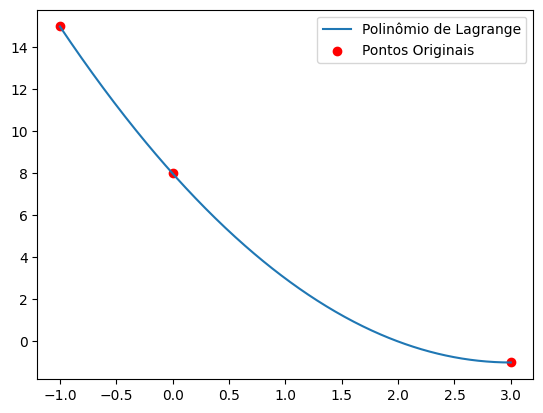

In [62]:
#Forma de Lagrange
def lagrange(xi,yi,N=100):

  n = len(xi)
  #Criamos o vetor x onde queremos avaliar o polinômio (entre o min e max de xi)
  #Função de linear space, cria sequÊncia de nuemros espaçados num intervalo def
  #nl.linspace(ini,fim,qnt)
  x = np.linspace(min(xi),max(xi),N)

  #Matriz L: cada linha i representa o polinômio base L_i avaliado em todo o vetor x
  L = np.ones((n,N))
  for i in range (n):
    for j in range (n):
      if i != j:
        #Fórmula de Lagrange: L_i(x) = Produtorio (x - xj) / (xi - xj)
        L[i,:] = L[i,:]*(x-xi[j])/(xi[i]-xi[j])

  #O polinômio final P(x) é a soma de yi * Li(x)
  #yi tem tamanho (n), L tem (n, N). O resultado 'y' terá tamanho (N)
  #A formula da somatória na teoria remete a um produto escalar do vetor y com os vetores colunas de L
  y = np.dot(yi,L)
  return x,y

pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = lagrange(pontos_x, pontos_y,500)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Polinômio de Lagrange')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()

O polinômio de Lagrange é definido como:$$P(x) = \sum_{i=0}^{n} y_i L_i(x)$$onde cada termo da base é:$$L_i(x) = \prod_{j=0, j \neq i}^{n} \frac{x - x_j}{x_i - x_j}$$

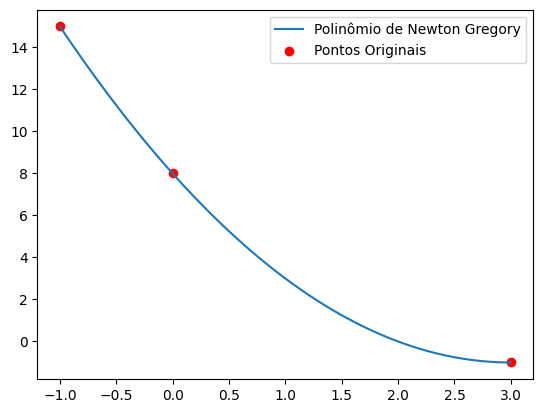

In [61]:
def diferenças_divididas(xi,yi):
  n = len(xi)
  D = np.zeros((n,n))
  #Preenche a 1ª coluna com val de y
  D[:,0] = yi.T
  for j in range (1, n):
    for i in range(j, n):
      #Calcula a inclinação entre os pontos. COmo se fosse um coef angular (delta y/delta x)
      #de forma sucessiva
       D[i,j] = (D[i,j-1]-D[i-1,j-1])/(xi[i]-xi[i-j])

  #C são os coeficientes formados pela diagonal de D que vamos usar
  c=np.diag(D)
  return c,D

def newton_gregory(xi,yi,N=100):
  n = len(xi)
  #Cria 100 pontos no eixo x para o grafico
  x = np.linspace(min(xi),max(xi),N)

  #pega os coef da diagonal de D
  coef, _ = diferenças_divididas(xi,yi)

  #Inicializamos o polinômio com o primeiro coeficiente c0
  y = np.ones(N)*coef[0]
  #Termo do produtório: (x - x0), depois (x - x0)(x - x1),...
  xv = np.ones(N)

  for i in range(1,n):
    #Pega o termo anterior e multiplica por x-xi[i-1]
    xv = xv*(x-xi[i-1])
    #Soma ao resultado a o coef da vez multiplicado pelos termos q estão acumulando
    y = y+coef[i]*xv
  return x,y


pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = newton_gregory(pontos_x, pontos_y)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Polinômio de Newton Gregory')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()


Diferente da forma que aprendemos na escola ($ax^2 + bx + c$), Newton organiza o polinômio de forma "aninhada". Para $n$ pontos, o polinômio é:$$P(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + c_3(x-x_0)(x-x_1)(x-x_2) + \dots$$

O termo produtório serve para construir os Polinômios de Base de Newton.Observe o padrão dos termos entre parênteses na fórmula acima:
Para o coeficiente $c_1$, o termo é $(x-x_0)$.

 Para o coeficiente $c_2$, o termo é $(x-x_0)(x-x_1)$.

Para o coeficiente $c_3$, o termo é $(x-x_0)(x-x_1)(x-x_2)$.

Matematicamente, estamos definindo:$$N_i(x) = \prod_{j=0}^{i-1} (x - x_j)$$

Realiza a Somatória (Combinação Linear). Cada coeficiente é uma Diferença Dividida ($c_i$) que você calculou na matriz $D$. A linha de código está executando exatamente esta parte da somatória:$$\sum_{i=1}^{n} c_i \cdot N_i(x)$$

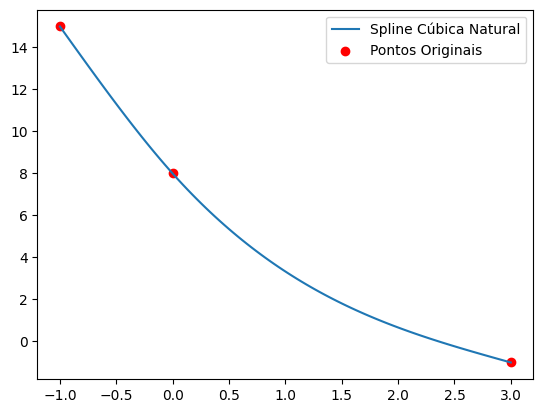

In [60]:
def spline_cubico_natural(xi,yi,N=100):
  n = len(xi)
  x = np.linspace(min(xi),max(xi),N)

  #número de intervalos
  m=n-1
  #vetor de intervalos
  h = np.zeros(n-1)
  #Calcula a distância no eixo x de cada sub-intervalo entre os pontos conhecidos
  h = np.diff(xi) # Calcula xi[i+1] - xi[i] para todos os i de uma vez

  #Matriz A (do sistema linear Ac = r) e o vetor de constantes r
  A = np.zeros((n,n))
  r = np.zeros(n)

  #Define a condição de 'Natural': a curvatura (2ª derivada) nos extremos é zero
  A[0,0] = 1
  A[m,m] = 1

  for i in range (1,n-1):
    #Monta a matriz tridiagonal baseada nas condições de continuidade das derivadas
    A[i,i-1] = h[i-1]
    A[i,i] = 2*(h[i-1]+h[i])
    A[i,i+1] = h[i]

    #Calcula os termos de r baseados nas inclinações (diferenças divididas) dos pontos
    r[i] = 3*((yi[i+1]-yi[i])/h[i]-(yi[i]-yi[i-1])/h[i-1])

  #Resolve o sistema linear para encontrar os coeficientes 'c' (relacionados à 2ª derivada)
  c = np.linalg.solve(A,r)
  #Coeficientes b (inclinação) e d (variação da curvatura) para cada pedaço da curva
  d = np.zeros(m)
  b = np.zeros(m)
  for i in range (m):
    #Fórmulas derivadas da exigência de que os pedaços se conectem perfeitamente
    d[i] = (c[i+1]-c[i])/(3*h[i])
    b[i] = (yi[i+1]-yi[i])/h[i]-(h[i]/3*(2*c[i]+c[i+1]))

  #Vetor de resultados do eixo vertical
  y = np.zeros(N)
  for i in range (N):
    #Determina em qual parte (intervalo) o ponto atual do gráfico se encaixa
    id = m-1
    for j in range (m):
      if x[i] <= xi[j+1]:
        id=j
        #Para qnd encontra o intervalo correto
        break
    #t é a distância local: o quanto o ponto x[i] avançou dentro do seu intervalo específico
    t=(x[i]-xi[id])
    #Calcula y usando o polinômio cúbico daquele intervalo: S(x) = a + bt + ct² + dt³
    y[i] = yi[id] +b[id]*t +c[id]*(t**2) +d[id]*(t**3)

  return x,y

pontos_x = np.array([-1,0,3])
pontos_y = np.array([15,8,-1])
x_eval, y_eval = spline_cubico_natural(pontos_x, pontos_y)

#Desenha as linhas, pega cada par (x,y) e liga
plt.plot(x_eval, y_eval, label='Spline Cúbica Natural')
#Desenha pontos isolados, gráfico de dispersão, para destacar os pontos que usamos para interpolação
plt.scatter(pontos_x, pontos_y, color='red', label='Pontos Originais')
#Pega os labels da de cima e monta a legenda
plt.legend()
#Exibe
plt.show()

### Tarefa prática para os métodos de Interpolação Polinomial

Utilizando os valores tabelados abaixo, responda aos itens **a**, **b** e **c**. Considere para os métodos um número $N = 100$ de pontos entre o $x$ inicial e final.

| $x$ | -5 | -1 | 2 | 8 | 10 | 17 | 19 | 24 | 33 | 36 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| $f(x)$ | 2,1 | 8,4 | 15,7 | 21,3 | 17,6 | 9,2 | 14,8 | 20,5 | 11,3 | 4,6 |

---

### Itens a serem resolvidos:

**a)** Determine o valor aproximado de $f(22)$ utilizando os interpoladores de Lagrange, Newton e Spline Cúbico Natural.

**b)** Plote, em um mesmo gráfico, as curvas geradas pelos três interpoladores (Lagrange, Newton e Spline Cúbico Natural) no intervalo $[-5, 36]$ e compare as curvas obtidas.

**c)** Utilizando cada curva gerada pelos interpoladores, determine o valor máximo e o valor mínimo de $f(x)$ no intervalo $[-5, 36]$.

In [59]:
#Exercício - letra A
N = 10000
x_a = np.array([-5., -1., 2., 8., 10., 17., 19., 24., 33., 36.])
y_a = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])


#Queremos o valor de y quando x=22, para isso 
#Encontramos o índice do valor de x_metodo mais próximo de 22 e pegamos o y correspondente
x_lagrange, y_lagrange = lagrange(x_a, y_a,N)
idl = np.argmin(np.abs(x_lagrange-22))
print(f'Método de Lagrange para f(22): {y_lagrange[idl]:.4f}')

x_newton, y_newton = newton_gregory(x_a, y_a,N)
idn = np.argmin(np.abs(x_newton-22))
print(f'Método de Newton para f(22): {y_newton[idn]:.4f}')

x_spline, y_spline = spline_cubico_natural(x_a, y_a,N)
ids = np.argmin(np.abs(x_spline-22))
print(f'Método de Spline Cúbica Natural para f(22): {y_spline[ids]:.4f}')


Método de Lagrange para f(22): 22.5981
Método de Newton para f(22): 22.5981
Método de Spline Cúbica Natural para f(22): 19.7935


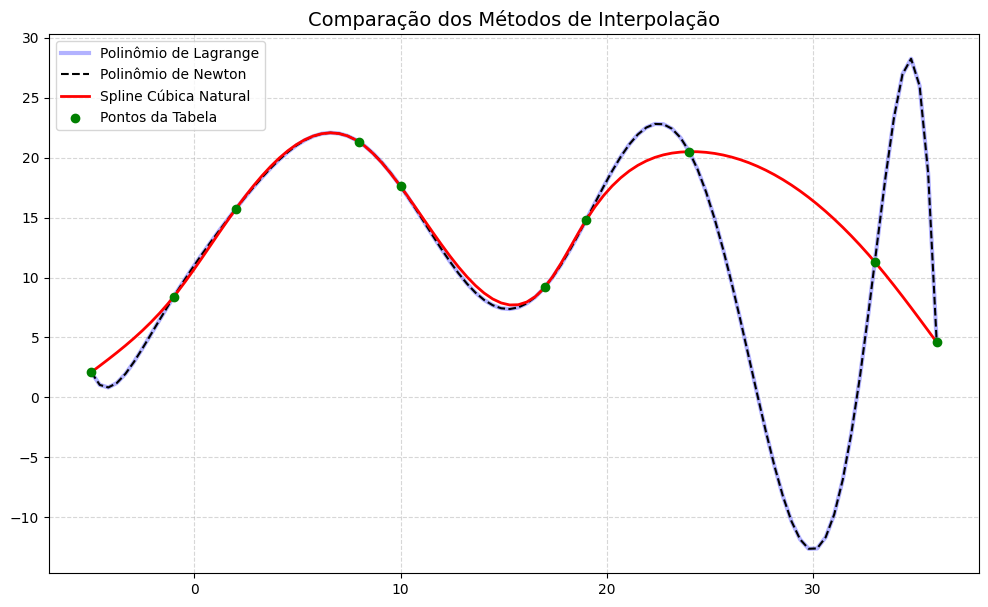

In [58]:
#Exercício - letra B
N = 100
x_b = np.array([-5., -1., 2., 8., 10., 17., 19., 24., 33., 36.])
y_b = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

x_lagrange, y_lagrange = lagrange(x_b, y_b,N)
x_newton, y_newton = newton_gregory(x_b, y_b,N)
x_spline, y_spline = spline_cubico_natural(x_b, y_b,N)

#Gráfico único
print('\n\n')
plt.figure(figsize=(12, 7))
plt.plot(x_lagrange, y_lagrange, color='blue', label='Polinômio de Lagrange', linewidth=3, alpha=0.3)
plt.plot(x_newton, y_newton, color='black', linestyle='--', label='Polinômio de Newton')
plt.plot(x_spline, y_spline, color='red', label='Spline Cúbica Natural', linewidth=2)
plt.scatter(x_b, y_b, color='green', zorder=5, label='Pontos da Tabela')
plt.title('Comparação dos Métodos de Interpolação', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [57]:
#Exercício - letra C
N = 100
x_c = np.array([-5., -1., 2., 8., 10., 17., 19., 24., 33., 36.])
y_c = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])


x_lagrange, y_lagrange = lagrange(x_c, y_c,N)
x_newton, y_newton = newton_gregory(x_c, y_c,N)
x_spline, y_spline = spline_cubico_natural(x_c, y_c,N)

#Máximo e mínimo
idx_max_l = np.argmax(y_lagrange)
idx_min_l = np.argmin(y_lagrange)
print(f'Método de Lagrange:') 
print(f'Ponto de Máximo: x = {x_lagrange[idx_max_l]:.4f}, y = {y_lagrange[idx_max_l]:.4f}')
print(f'Ponto de Mínimo: x = {x_lagrange[idx_min_l]:.4f}, y = {y_lagrange[idx_min_l]:.4f}\n')

idx_max_n = np.argmax(y_newton)
idx_min_n = np.argmin(y_newton)
print(f'Método de Newton:') 
print(f'Ponto de Máximo: x = {x_newton[idx_max_n]:.4f}, y = {y_newton[idx_max_n]:.4f}')
print(f'Ponto de Mínimo: x = {x_newton[idx_min_n]:.4f}, y = {y_newton[idx_min_n]:.4f}\n')

idx_max_s = np.argmax(y_spline)
idx_min_s = np.argmin(y_spline)
print(f'Método de Spline Cúbica Natural:') 
print(f'Ponto de Máximo: x = {x_spline[idx_max_s]:.4f}, y = {y_spline[idx_max_s]:.4f}')
print(f'Ponto de Mínimo: x = {x_spline[idx_min_s]:.4f}, y = {y_spline[idx_min_s]:.4f}\n')


Método de Lagrange:
Ponto de Máximo: x = 34.7576, y = 28.2471
Ponto de Mínimo: x = 29.7879, y = -12.6288

Método de Newton:
Ponto de Máximo: x = 34.7576, y = 28.2471
Ponto de Mínimo: x = 29.7879, y = -12.6288

Método de Spline Cúbica Natural:
Ponto de Máximo: x = 6.5960, y = 22.0704
Ponto de Mínimo: x = -5.0000, y = 2.1000

